In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [7]:
DATASET_PATH = "fire_dataset"        # Path to your folder containing 'fire' and 'no_fire'
MODEL_SAVE_PATH = "models/fire_cnn_model.h5" # Name of the file where the trained model will be saved
IMG_SIZE = (224, 224)                 # MobileNetV2 strictly requires 224x224 pixels
BATCH_SIZE = 32                       # Number of images processed at once (32 is standard)
EPOCHS = 15                           # Number of times to go through the entire dataset
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

In [8]:
print("📂 Loading dataset from folders...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,   # Use 80% of images for training
    subset="training",
    seed=42,                # Random seed for reproducibility
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Using 800 files for training.


In [9]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Using 199 files for validation.


In [10]:
class_names = train_dataset.class_names
print(f"✅ Found classes: {class_names}\n")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

✅ Found classes: ['fire', 'no_fire']



In [11]:

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip('horizontal'),   # Flip left/right
  layers.RandomRotation(0.2),        # Rotate by 20%
  layers.RandomZoom(0.2),            # Zoom in/out by 20%
])

In [12]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
model = models.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    data_augmentation,

    tf.keras.layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),
     layers.Dense(1, activation='sigmoid')
])


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # Keep the best version of the model, not the last one
)

# 2. Model Checkpoint: Save the model to a file every time it gets a new best accuracy
checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint] # Add our smart features here
)


25/25 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.9925 - loss: 0.0211 - val_accuracy: 0.7387 - val_loss: 1.0953


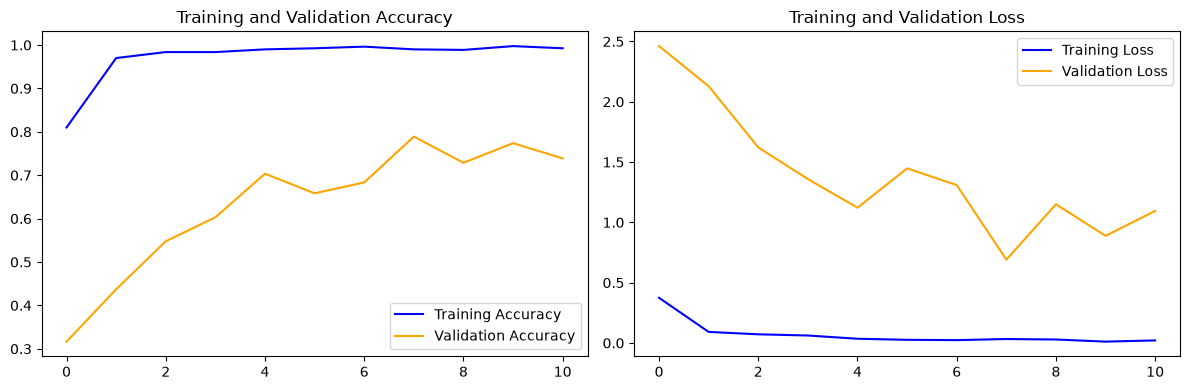

In [19]:
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

     # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.savefig('cnn_training_results.png') # Save the graph as an image
    print("\n📊 Training graph saved as: cnn_training_results.png")
    plt.show()

plot_learning_curves(history)


In [20]:

print(f"\n🎉 ALL DONE! Your trained model is saved as: {MODEL_SAVE_PATH}")
print("You can now use this .h5 file in your Django application to make predictions.")


🎉 ALL DONE! Your trained model is saved as: models/fire_cnn_model.h5
You can now use this .h5 file in your Django application to make predictions.
